# Highlighting IDRs and motifs in AIUPred results

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
idr_positions = {
    "Lsr2": [(61, 76)],
    "EspD": [(1, 14), (35, 60), (171, 184)],
    "EspA": [(270, 294), (301, 383)],
    "EspM": [(1, 34), (131, 161), (230, 249)],
    "EspE": [(204, 277), (361, 402)],
    "EspH": [(1, 33)],
    "PPE68": [(173, 202), (236, 368)],
    "EspI": [(1, 246), (257, 311), (325, 373)],
    "EspJ": [(97, 113), (176, 280)],
    "EspK": [(175, 461)],
    "EspB": [(93, 124), (265, 335), (352, 433), (453, 460)]
}

motif_data = {
    'PPE68': [(341, 343), (265, 267)],
    'EspA': [(346, 348), (279, 281)],
    'EspB': [(456, 460), (456, 460), (459, 460), (384, 386)],
    'EspE': [(368, 370)],
    'EspI': [(57, 59), (206, 208), (217, 219), (286, 288), (351, 353), (1, 4)],
    'EspJ': [(196, 198), (257, 259), (102, 104)],
    'EspK': [(252, 254), (329, 331)],
    'EspM': [(146, 148), (246, 248), (1, 4)]
}

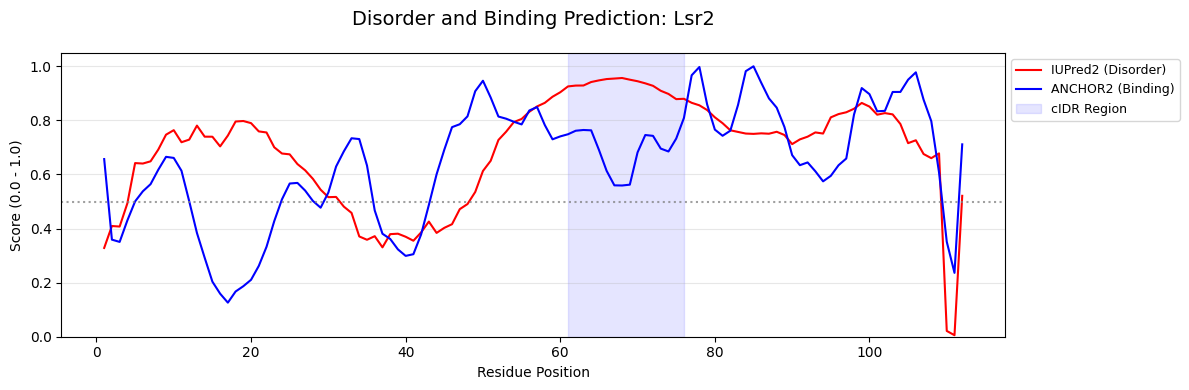

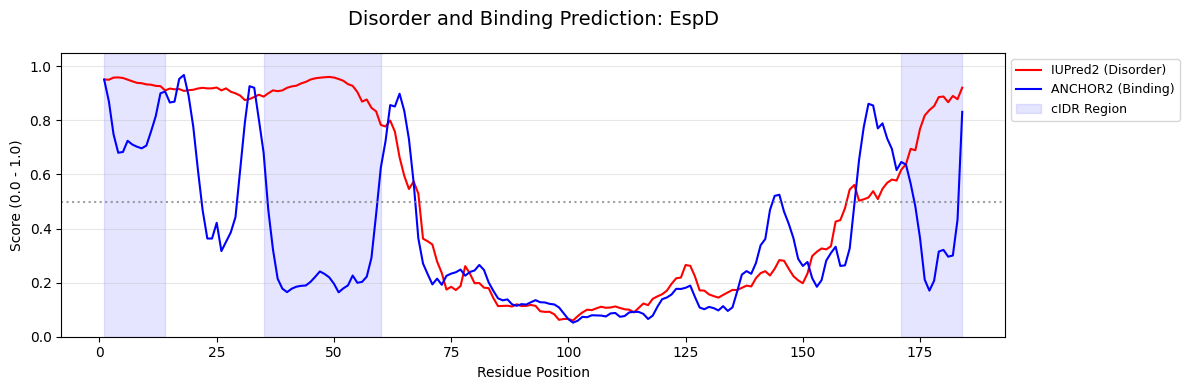

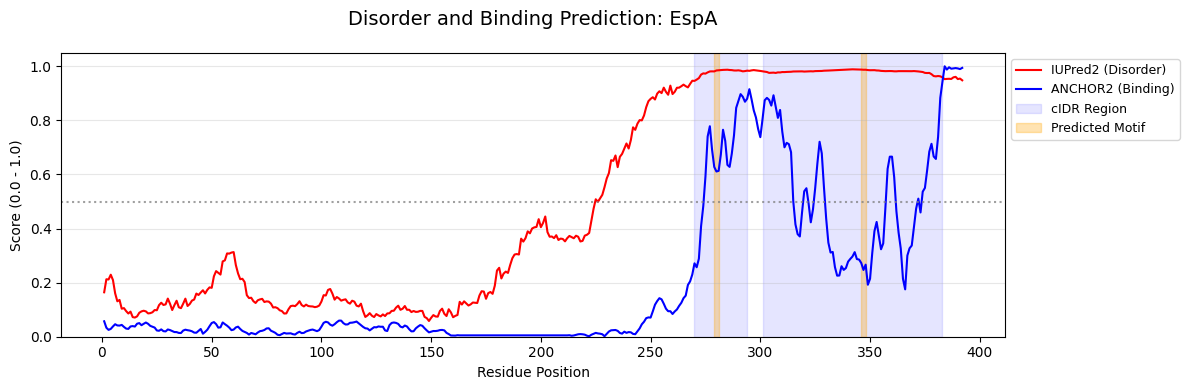

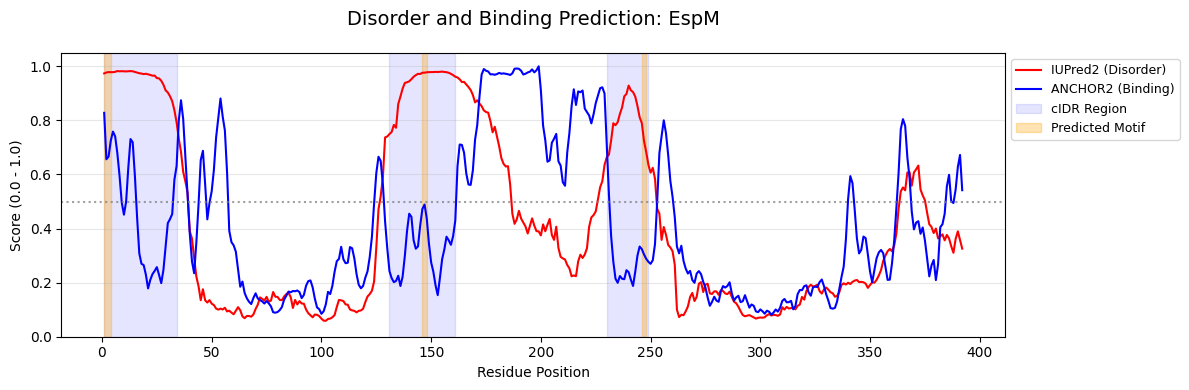

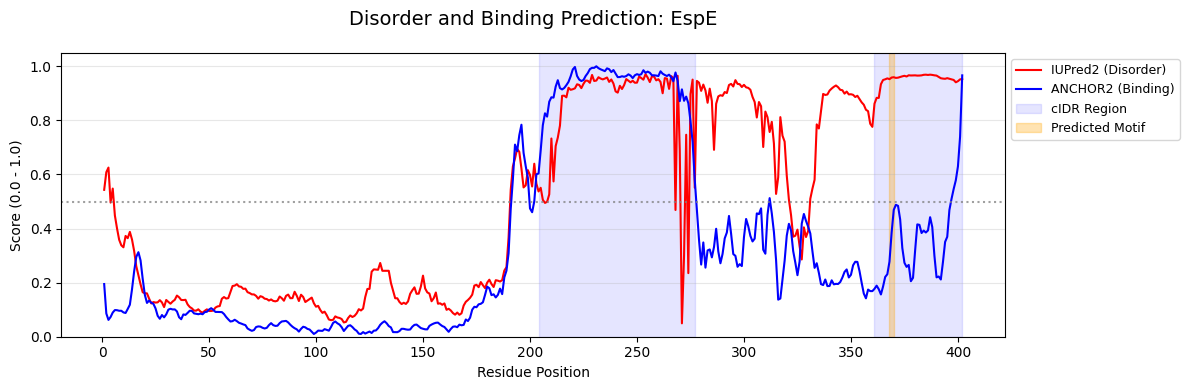

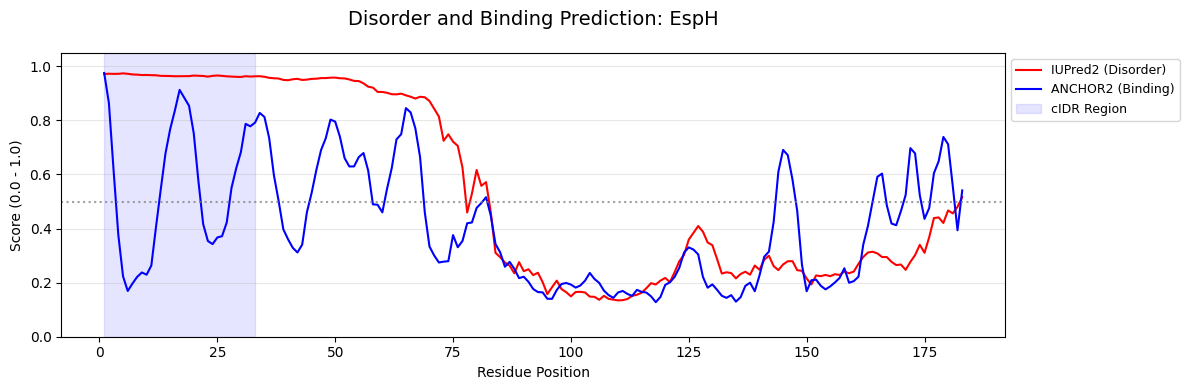

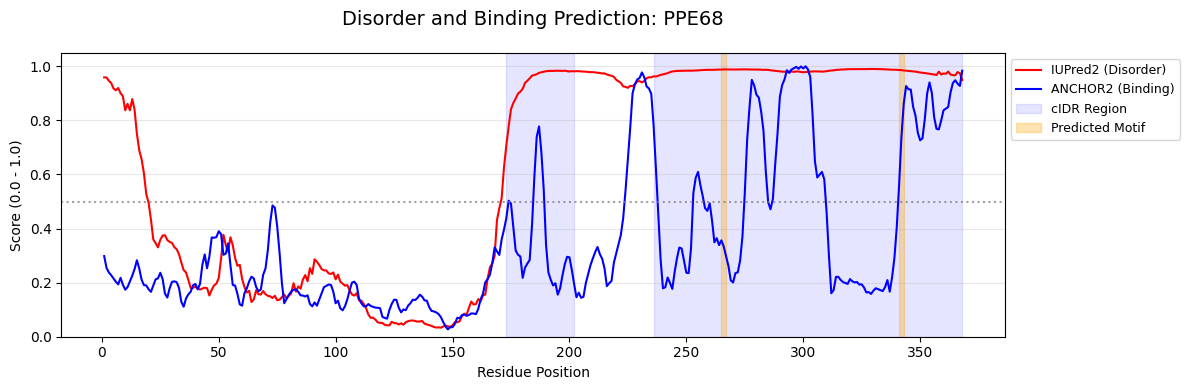

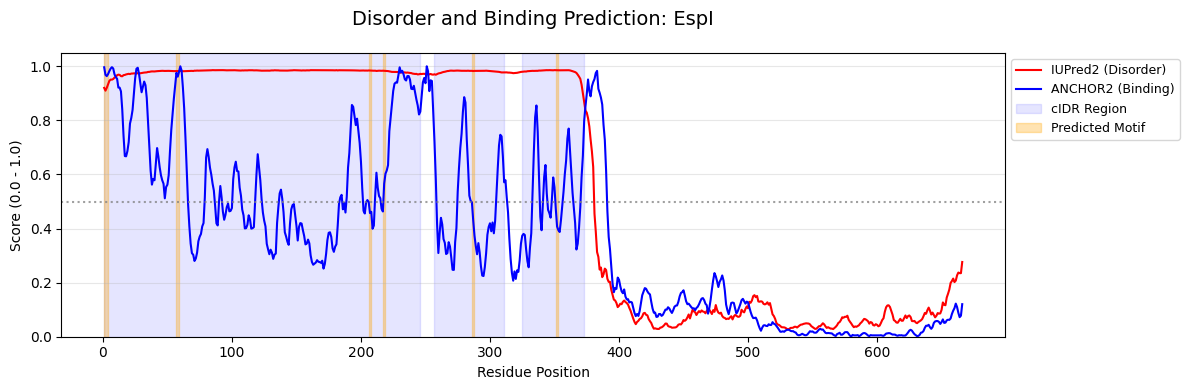

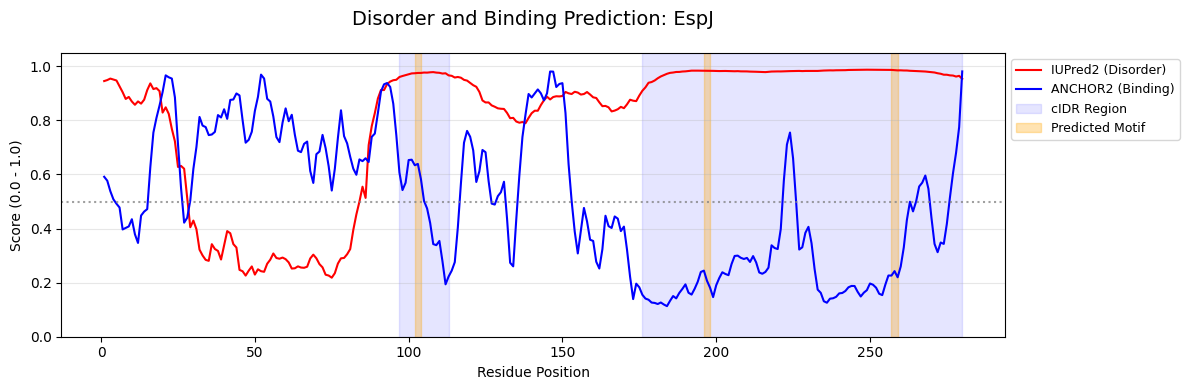

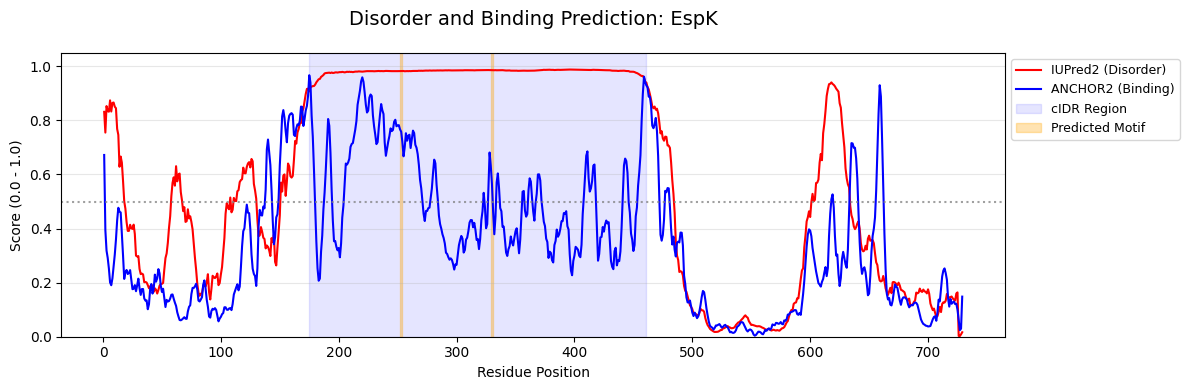

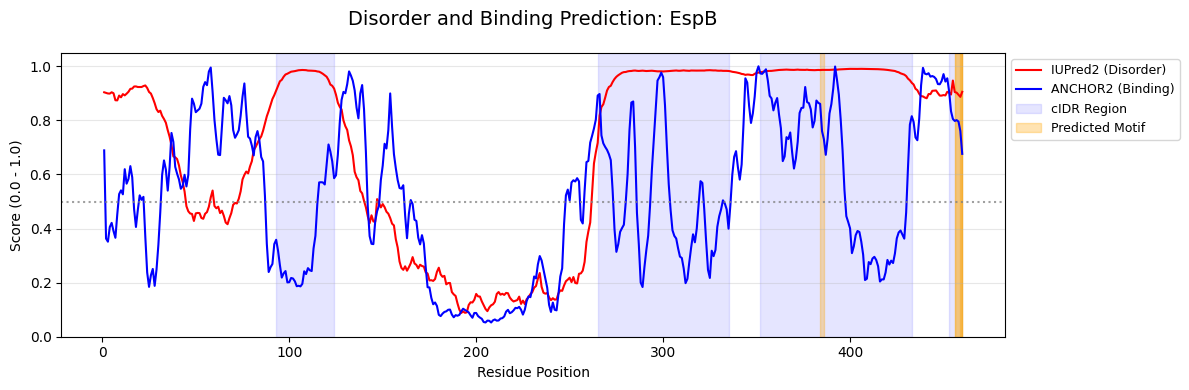

In [ ]:

df = pd.read_excel("D:/2nd  year/2nd term/Thesis/after_exams/iupred2a_anchor2/AIUPred/all_esx1.xlsx")
idr_lookup = {k.lower(): v for k, v in idr_positions.items()}  # Convert dictionary keys to lowercase for robust lookup
motif_lookup = {k.lower(): v for k, v in motif_data.items()}
for prot_name in df['Protein'].unique():
    df_prot = df[df['Protein'] == prot_name].sort_values('#')
    prot_lower = prot_name.lower().strip()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_prot['#'], df_prot['Residue'], label='IUPred2 (Disorder)', color='red', lw=1.5)
    ax.plot(df_prot['#'], df_prot['ANCHOR2'], label='ANCHOR2 (Binding)', color='blue', lw=1.5)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.75)
    if prot_lower in idr_lookup:
        for start, end in idr_lookup[prot_lower]:
            ax.axvspan(start, end, color='blue', alpha=0.1, label='cIDR Region' if start == idr_lookup[prot_lower][0][0] else "")
    if prot_lower in motif_lookup:
        for i, (m_start, m_end) in enumerate(motif_lookup[prot_lower]):
            motif_label = 'Predicted Motif' if i == 0 else ""
            ax.axvspan(m_start, m_end, color='orange', alpha=0.3, zorder=1, label=motif_label)
    ax.set_title(f"Disorder and Binding Prediction: {prot_name}", fontsize=14, pad=20)
    ax.set_xlabel("Residue Position")
    ax.set_ylabel("Score (0.0 - 1.0)")
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()